In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.text_utils import clean_html

/home/p1xta/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
analysis = pd.read_feather("analysis_predictions.feather")
articles = pd.read_feather("candidate_data/articles.f")

articles["body_clean"] = articles["body"].apply(clean_html)
articles["body_len"] = articles["body_clean"].str.len()
articles["title_len"] = articles["title"].str.len()

articles = articles.set_index("article_id")
article_len = articles["body_len"].to_dict()

In [3]:
def average_precision_at_10(pred_ids, gt_ids):
    if not gt_ids:
        return 0.0

    hits = 0
    ap_sum = 0.0

    for i, pid in enumerate(pred_ids[:10], start=1):
        if pid in gt_ids:
            hits += 1
            ap_sum += hits / i

    return ap_sum / min(len(gt_ids), 10)

In [4]:
analysis["gt"] = analysis["ground_truth"].apply(
    lambda x: {int(i) for i in str(x).split()}
)

analysis["prediction"] = analysis["prediction"].apply(list)

analysis["ap10"] = analysis.apply(
    lambda r: average_precision_at_10(r["prediction"], r["gt"]),
    axis=1,
)

analysis["hits"] = analysis.apply(
    lambda r: len(set(r["prediction"][:10]) & r["gt"]),
    axis=1,
)

analysis["gt_lengths"] = analysis["gt"].apply(
    lambda ids: [article_len.get(i, None) for i in sorted(ids)]
)

analysis["gt_mean_len"] = analysis["gt_lengths"].apply(np.mean)

analysis["gt_lengths"] = analysis["gt_lengths"].apply(
    lambda x: ", ".join(map(str, x))
)

analysis["num_gt"] = analysis["gt"].apply(len)

analysis["query_len"] = analysis["query_text"].apply(len)

In [5]:
best = analysis.sort_values("ap10", ascending=False)
worst = analysis.sort_values("ap10")

In [6]:
worst.head(10)[
    [
        "query_text",
        "ap10",
        "hits",
        "num_gt",
        "query_len",
        "gt_lengths"
    ]
]

,query_text,ap10,hits,num_gt,query_len,gt_lengths
497,Почему нету доставки за <MONEY>?,0.0,0,2,32,"1391, 35123"
493,Магу ли я отправить авито доставкой,0.0,0,1,35,20480
478,"Подскажите, я хочу выставить объявление по усл...",0.0,0,1,112,21778
477,Здравствуйте хочу купить фару на авто но при о...,0.0,0,1,73,19534
479,"Здравствуйте. При просмотре ""Мои объявления"" п...",0.0,0,2,143,"9607, 9623"
38,"Приветствую, почему деньги на кошелек зачисляются",0.0,0,1,49,21705
40,Прошу вернуть деньги.Я вам отправила чек.Вы об...,0.0,0,2,115,"14948, 11955"
39,По ошибке отправили более дорогой товар. Модно...,0.0,0,1,80,7902
287,"Хочу разместить объявление о продаже, но мне в...",0.0,0,1,65,28075
322,Мое объявление почему то списывает деньги с мо...,0.0,0,1,100,35123


In [7]:
best.head(10)[
    [
        "query_text",
        "ap10",
        "hits",
        "num_gt",
        "query_len",
        "gt_lengths"
    ]
]

,query_text,ap10,hits,num_gt,query_len,gt_lengths
480,А сколько стоит доставка для меня в этом объяв...,1.0,1,1,51,1391
31,Как упаковать покупку для отправки,1.0,1,1,34,6349
431,"Здравствуйте, только сейчас оплатила заказ на ...",1.0,1,1,116,14948
437,Почему у меня нельзя списать бонусы? Почему с ...,1.0,1,1,113,14948
435,"Что то именно с заказом , другие покупки карта...",1.0,1,1,79,4544
48,Клиент просит отправить книгу доставкой,1.0,1,1,39,20480
41,Я хочу сделать заказ. В графе доставка лучшая ...,1.0,1,1,138,1391
451,Отмените скидки на моих объявлениях,1.0,1,1,35,5275
440,Как отправить коляску детскую Авито доставкой,1.0,1,1,45,35123
453,"Здравствуйте. Прохожу проверку авто, запрашива...",1.0,1,1,87,1079


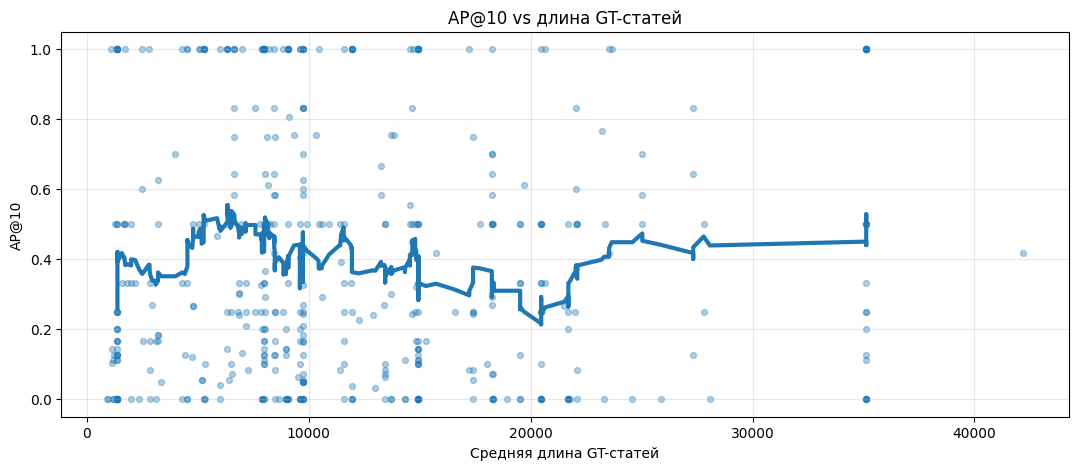

In [8]:
tmp = (
    analysis
    .sort_values("gt_mean_len")
    .reset_index(drop=True)
)

tmp["ap_smooth"] = (
    tmp["ap10"]
    .rolling(30, center=True)
    .mean()
)

plt.figure(figsize=(13,5))

plt.scatter(
    tmp["gt_mean_len"],
    tmp["ap10"],
    s=18,
    alpha=0.35,
)

plt.plot(
    tmp["gt_mean_len"],
    tmp["ap_smooth"],
    linewidth=3,
)

plt.xlabel("Средняя длина GT-статей")
plt.ylabel("AP@10")
plt.title("AP@10 vs длина GT-статей")

plt.grid(alpha=0.3)

plt.show()

In [9]:
analysis["gt_str"] = analysis["gt"].apply(
    lambda x: " ".join(map(str, sorted(x)))
)

analysis["pred_str"] = analysis["prediction"].apply(
    lambda x: " ".join(map(str, x))
)

summary = (
    analysis[
        [
            "query_text",
            "gt_str",
            # "pred_str",
            "ap10",
            "hits",
            # "num_gt",
            "gt_lengths"
        ]
    ]
    .reset_index(drop=True)
)

summary.head(20)

,query_text,gt_str,ap10,hits,gt_lengths
0,Как передать товар через службу авито,1909 4234,0.833333,2,"8981, 35123"
1,"Можете подсказать, если заказать товар Авито д...",2865 4400,0.071429,1,"1131, 11955"
2,Здравствуйте. Как отправить товар через Авито.,1909,0.125000,1,8981
3,как получить деньги за возрат если продавец уж...,4400 4403,0.750000,2,"11955, 4310"
4,"Когда мне прийдут деньги за доставку, сегодня ...",4361,1.000000,1,9088
5,Почему пишете что доставка <MONEY> а когда опл...,1951,0.000000,0,1391
6,Почему такая Большая сумма доставки из Москлвс...,1951,0.000000,0,1391
7,"Добрый вечер , выбираю способ оплаты при получ...",2646 4219,1.000000,2,"4544, 14948"
8,Авито теперь не работает за наличку??,2646 4219,0.000000,0,"4544, 14948"
9,"хочу отменить заказ,мне вернут полную сумму?",4219 4387,0.500000,1,"14948, 7902"


In [11]:
def error_type(row):
    gt = set(row["gt"])
    pred = row["prediction"][:10]

    if row["ap10"] == 1:
        return "Perfect"

    hits = [p for p in pred if p in gt]

    if len(hits) == 0:
        return "Miss"

    if pred[0] not in gt:
        return "Ranking"

    return "Partial"

analysis["error_type"] = analysis.apply(error_type, axis=1)

analysis["error_type"].value_counts()

error_type
Ranking    230
Miss       102
Perfect     97
Partial     71
Name: count, dtype: int64

In [14]:
def first_hit(row):
    gt = set(row["gt"])
    for i, p in enumerate(row["prediction"], 1):
        if p in gt:
            return i
    return None

analysis["first_hit"] = analysis.apply(first_hit, axis=1)

first_hit
1.0     168
2.0      66
3.0      31
4.0      34
5.0      18
6.0      19
7.0      19
8.0      15
9.0      13
10.0     15
Name: count, dtype: int64


<Axes: >

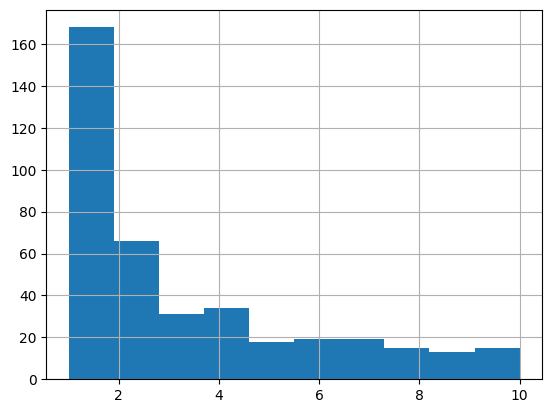

In [17]:
print(analysis["first_hit"].value_counts().sort_index())
analysis["first_hit"].hist(bins=10)

In [18]:
from collections import Counter

miss_counter = Counter()

for _, row in analysis.iterrows():
    if row["first_hit"] is None:
        miss_counter.update(row["gt"])

pd.DataFrame(miss_counter.items(), columns=["article_id","count"]).sort_values("count", ascending=False).head(30)

,article_id,count


In [23]:
article_ap = []

for aid in articles.index:

    rows = analysis[
        analysis["gt"].apply(lambda x: aid in x)
    ]

    if len(rows):

        article_ap.append({
            "article_id": aid,
            "count": len(rows),
            "mean_ap": rows.ap10.mean(),
            "title": articles.loc[aid, "title"],
        })

article_ap = pd.DataFrame(article_ap)

article_ap.sort_values("mean_ap").head(20)

,article_id,count,mean_ap,title
7,2202,1,0.000000,Не сохраняются изменения
9,2222,2,0.000000,Ошибка при подаче объявления через приложение
28,3261,1,0.000000,Отзыв отклонили
21,2943,1,0.000000,Не могу вывести деньги за доставку
51,4273,1,0.000000,Ошибки сайта или приложения
41,4133,1,0.000000,Ограничены звонки и чаты с покупателями
47,4224,1,0.000000,Предложить услугу
45,4218,1,0.000000,Тариф с оплатой за просмотры в Товарах
53,4283,2,0.000000,Ошибки сайта или приложения
19,2908,1,0.037037,"Нужно подтвердить, что вы собственник"
